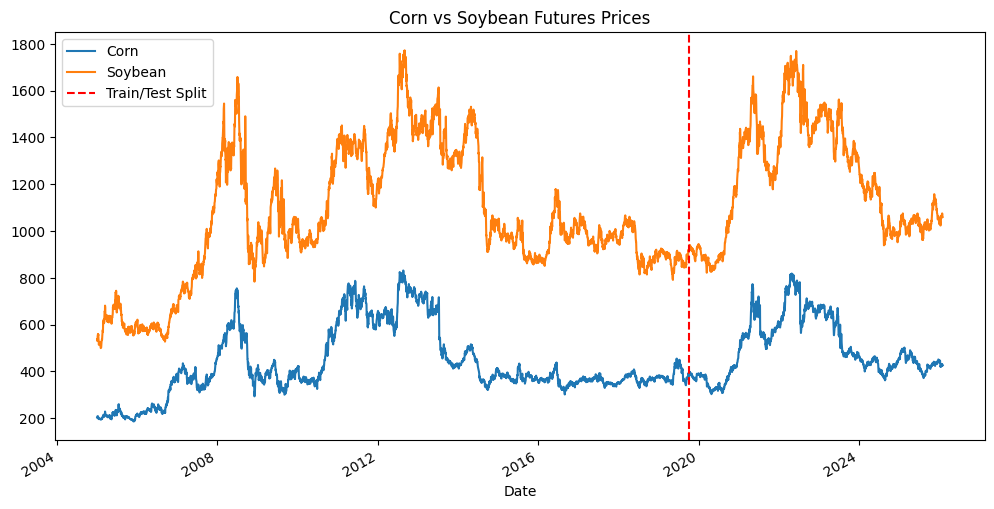

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

df1=pd.read_csv(r'/Users/wiktor/TIC/Spring2026-TIC/data/daily_corn_prices.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['Close']

df2=pd.read_csv(r'/Users/wiktor/TIC/Spring2026-TIC/data/daily_soybean_prices.csv', skiprows=[1], index_col=0, parse_dates=True)
soybean=df2['Close']

df=pd.merge(left=corn, right=soybean, left_index=True, right_index=True, how='inner')
df.columns=['Corn', 'Soybean']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Corn vs Soybean Futures Prices')
plt.legend()
plt.show()


In [2]:
adf_corn=adfuller(df_train['Corn'])
adf_soybean=adfuller(df_train['Soybean'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'Critical Values: {adf_soybean[4]}')

ADF Statistic for Corn: -2.051074831001558
p-value for Corn: 0.2646369229222725
ADF Statistic for Soybean: -2.4232965313063155
p-value for Soybean: 0.13526879637905292
Critical Values: {'1%': np.float64(-3.4321248463781306), '5%': np.float64(-2.862324228723766), '10%': np.float64(-2.5671874564323343)}


In [3]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'Critical Values: {adf_soybean_diff[4]}')

ADF Statistic for Corn: -13.265508877822079
p-value for Corn: 8.234102570598829e-25
ADF Statistic for Soybean: -12.52745846904757
p-value for Soybean: 2.4705439183902594e-23
Critical Values: {'1%': np.float64(-3.4321248463781306), '5%': np.float64(-2.862324228723766), '10%': np.float64(-2.5671874564323343)}


                            OLS Regression Results                            
Dep. Variable:                Soybean   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                 1.294e+04
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:28:41   Log-Likelihood:                -23356.
No. Observations:                3712   AIC:                         4.672e+04
Df Residuals:                    3710   BIC:                         4.673e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        328.2656      6.598     49.756      0.0

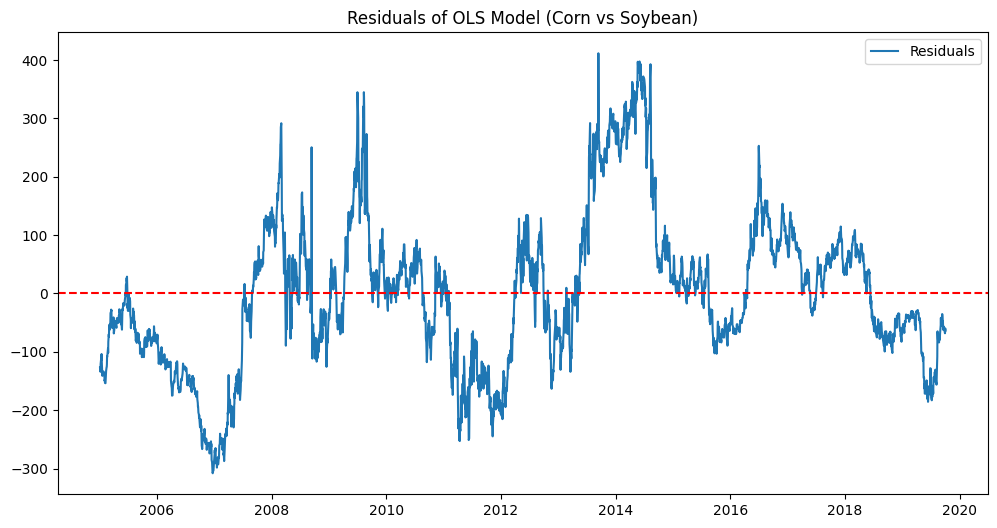

In [4]:
X_1=sm.add_constant(df_train['Corn'])
y_1=df_train['Soybean']
model_1=sm.OLS(y_1,X_1)
result_1=model_1.fit()
print(result_1.summary())

plt.figure(figsize=(12, 6))

plt.plot(result_1.resid, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of OLS Model (Corn vs Soybean)')
plt.legend()
plt.show()


In [5]:
adf_residuals_1=adfuller(result_1.resid, maxlag=1)
print(f'ADF Statistic for residuals: {adf_residuals_1[0]}')
print(f'p-value for residuals: {adf_residuals_1[1]}')
print(f'Critical Values: {adf_residuals_1[4]}')

ADF Statistic for residuals: -3.7889705361480437
p-value for residuals: 0.003022198279214669
Critical Values: {'1%': np.float64(-3.4321138356601963), '5%': np.float64(-2.8623193649997063), '10%': np.float64(-2.567184867154409)}


In [6]:
X_2=sm.add_constant(df_train['Soybean'])
y_2=df_train['Corn']
model_2=sm.OLS(y_2,X_2)
result_2=model_2.fit()
print(result_2.summary())

adf_residuals_2=adfuller(result_2.resid, maxlag=1)
print(f'ADF Statistic for residuals: {adf_residuals_2[0]}')
print(f'p-value for residuals: {adf_residuals_2[1]}')
print(f'Critical Values: {adf_residuals_2[4]}')

                            OLS Regression Results                            
Dep. Variable:                   Corn   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                 1.294e+04
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:28:45   Log-Likelihood:                -20997.
No. Observations:                3712   AIC:                         4.200e+04
Df Residuals:                    3710   BIC:                         4.201e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -58.2693      4.409    -13.215      0.0

## CADF Test Results

We tested both variable orderings following Chan (2013) Example 2.6.

| Order | ADF Statistic | p-value | Conclusion |
|-------|--------------|---------|------------|
| Soybean = β*Corn + μ | -3.789 | 0.003 | Cointegrated |
| Corn = β*Soybean + μ | -3.696 | 0.004 | Cointegrated |

Both orderings confirm cointegration at the 95% confidence level.
We select **Order 1 (Soybean as dependent variable)** because it produces 
the more negative t-statistic (-3.789 vs -3.696), as recommended by the book.

The spread for the rest of the analysis is:
$$Spread = Soybean - 1.6645 \times Corn - 328.27$$

In [7]:
spread=result_1.resid
spread_diff=spread.diff().dropna()
spread_lagged=spread.shift(1).dropna()
spread_lagged=sm.add_constant(spread_lagged)
model_3=sm.OLS(spread_diff, spread_lagged)
result_3=model_3.fit()
print(result_3.summary())
lambda_val=result_3.params[0]
half_life=-np.log(2)/lambda_val
print(f"Half life :{half_life:.1f} days")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     15.53
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           8.28e-05
Time:                        16:28:48   Log-Likelihood:                -15703.
No. Observations:                3711   AIC:                         3.141e+04
Df Residuals:                    3709   BIC:                         3.142e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0172      0.273      0.063      0.9

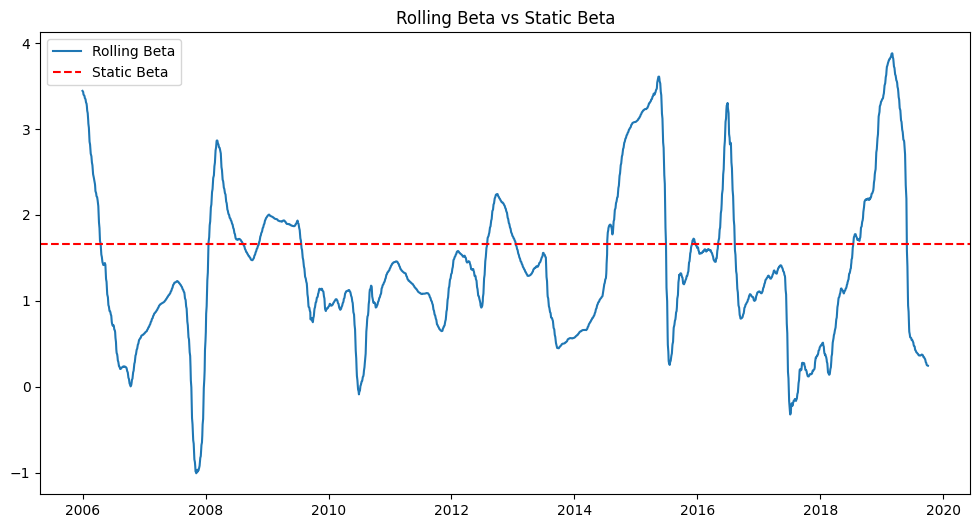

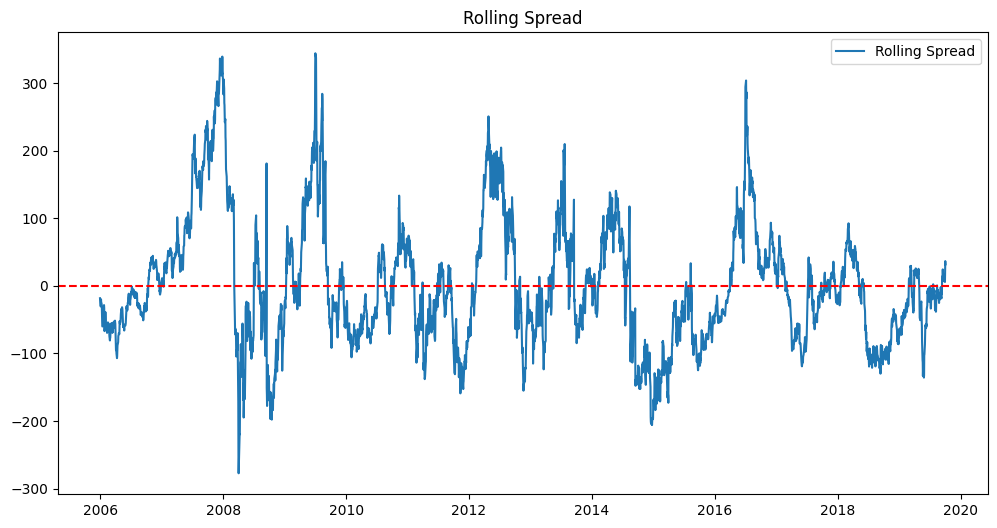

In [8]:
lookback=252
betas=np.full(len(df_train), np.nan)
mus=np.full(len(df_train), np.nan)
rolling_spread=np.full(len(df_train), np.nan)

for i in range(lookback, len(df_train)):
  corn_window=df_train['Corn'].iloc[i-lookback:i]
  soy_window=df_train['Soybean'].iloc[i-lookback:i]

  X_3=sm.add_constant(corn_window)
  y_3=soy_window
  model_4=sm.OLS(y_3, X_3)
  result_4=model_4.fit()
  betas[i]=result_4.params['Corn']
  mus[i]=result_4.params['const']
  rolling_spread[i]=result_4.resid.iloc[-1] 


plt.figure(figsize=(12,6))
plt.plot(df_train.index, betas, label='Rolling Beta')
plt.axhline(y=1.6645, color='red', linestyle='--', label='Static Beta')
plt.title('Rolling Beta vs Static Beta')
plt.legend()
plt.show()


plt.figure(figsize=(12,6))
plt.plot(df_train.index, rolling_spread, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread')
plt.legend()
plt.show()


{1.0: np.float64(0.5803074372545026), 1.5: np.float64(0.6793698780326936), 2.0: np.float64(0.5887333032332333), 2.5: np.float64(0.5264464410388655), 3.0: np.float64(0.5522566768908275)}
Best threshold: 1.5


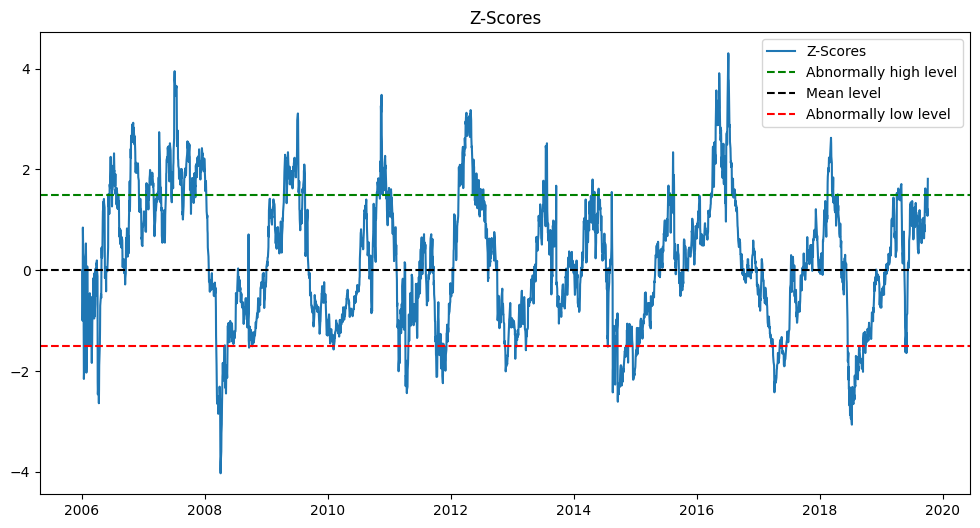

In [9]:
rolling_spread_series=pd.Series(rolling_spread, index=df_train.index)
z_scores=np.full(len(rolling_spread_series), np.nan)
for i in range(lookback, len(rolling_spread_series)):
  window_rolling_spread=rolling_spread_series.iloc[i-lookback:i]
  mean_rolling_spread=np.mean(window_rolling_spread)
  std_rolling_spread=np.std(window_rolling_spread)
  if std_rolling_spread == 0:
    z_scores[i] = 0
  else:
    z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread


thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results = {}

for entry in thresholds:
    positions=np.zeros(len(z_scores))
    position=0

    for j in range(len(z_scores)):
      if np.isnan(z_scores[j]):
        position=0
      elif z_scores[j]>=entry:
        position=-1
      elif z_scores[j]<=-entry:
        position=1
      elif position==1 and z_scores[j]>=0:
        position=0
      elif position==-1 and z_scores[j]<=0:
        position=0
      positions[j]=position
    
    spread_changes=rolling_spread_series.diff()
    pnl=positions*spread_changes
    
    sharpe_ratio=np.mean(pnl)/np.std(pnl)*np.sqrt(252)

    results[entry]=sharpe_ratio
    
best_threshold = max(results, key=results.get)
print(results)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores')
plt.legend()
plt.show()

## Parameter Optimization Results
Tested thresholds: 1.0, 1.5, 2.0, 2.5, 3.0
Optimal threshold on training data: **1.5**
Sharpe ratio: **0.679**
This threshold will be applied to the test set.

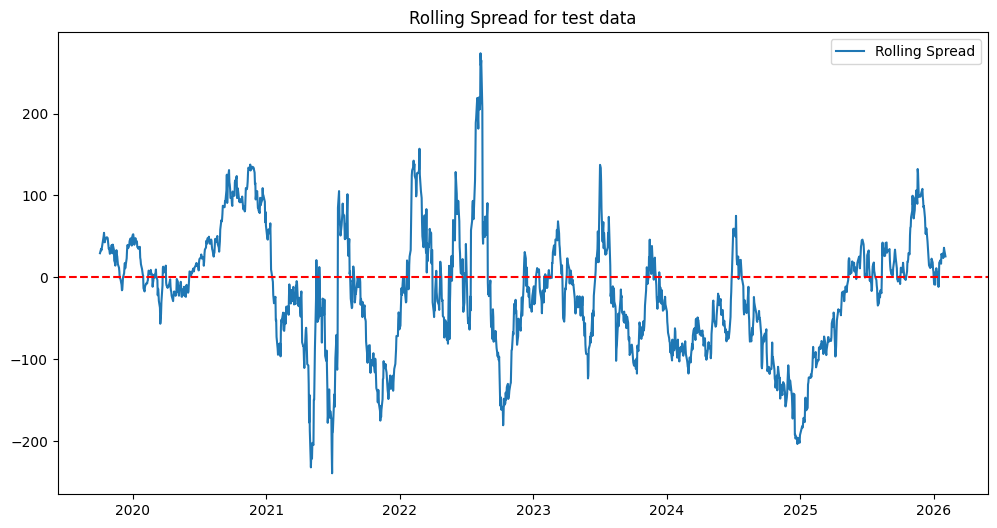

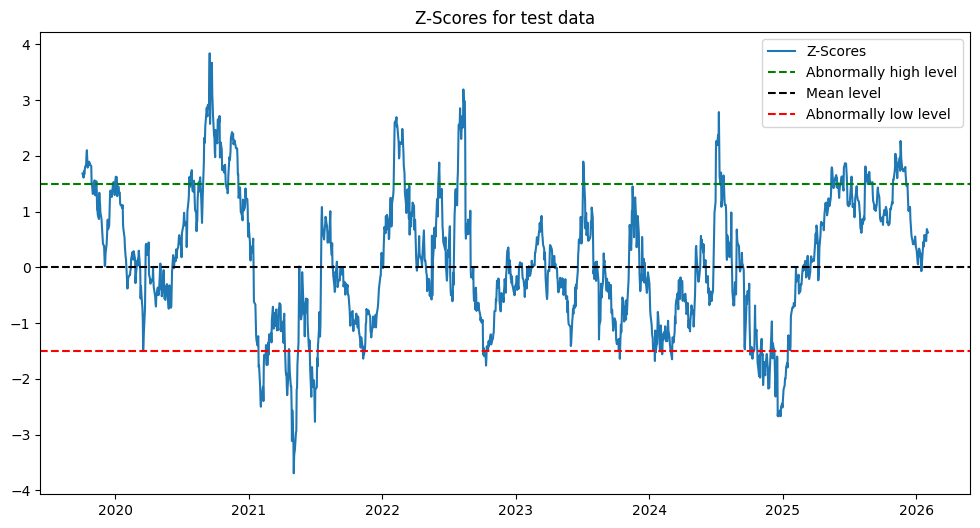

In [10]:
LOOKBACK=252
THRESHOLD=1.5

betas_final=np.full(len(df), np.nan)
spread_final=np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
  corn_window1=df['Corn'].iloc[i-LOOKBACK:i]
  soybean_window1=df['Soybean'].iloc[i-LOOKBACK:i]
  X_final=sm.add_constant(corn_window1)
  y_final=soybean_window1
  model_final=sm.OLS(y_final, X_final)
  result_final=model_final.fit()

  betas_final[i]=result_final.params['Corn']
  spread_final[i]=result_final.resid.iloc[-1]

spread_final_series=pd.Series(spread_final, index=df.index)
z_scores_final=np.full(len(spread_final_series), np.nan)

for j in range(LOOKBACK, len(df)):
  window_spread_final=spread_final_series.iloc[j-LOOKBACK:j]
  mean_spread_final=np.mean(window_spread_final)
  std_spread_final=np.std(window_spread_final)
  if std_spread_final==0:
    z_scores_final[j]=0
  else:
    z_scores_final[j]=(window_spread_final.iloc[-1]-mean_spread_final)/std_spread_final

z_scores_final_series=pd.Series(z_scores_final, index=df.index)
z_scores_test= z_scores_final_series[df.index>=df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()

Sharpe Ratio:   0.071
Total Return:   1.40%
Max Drawdown:   -39.64%
Total P&L (pts): 459.79


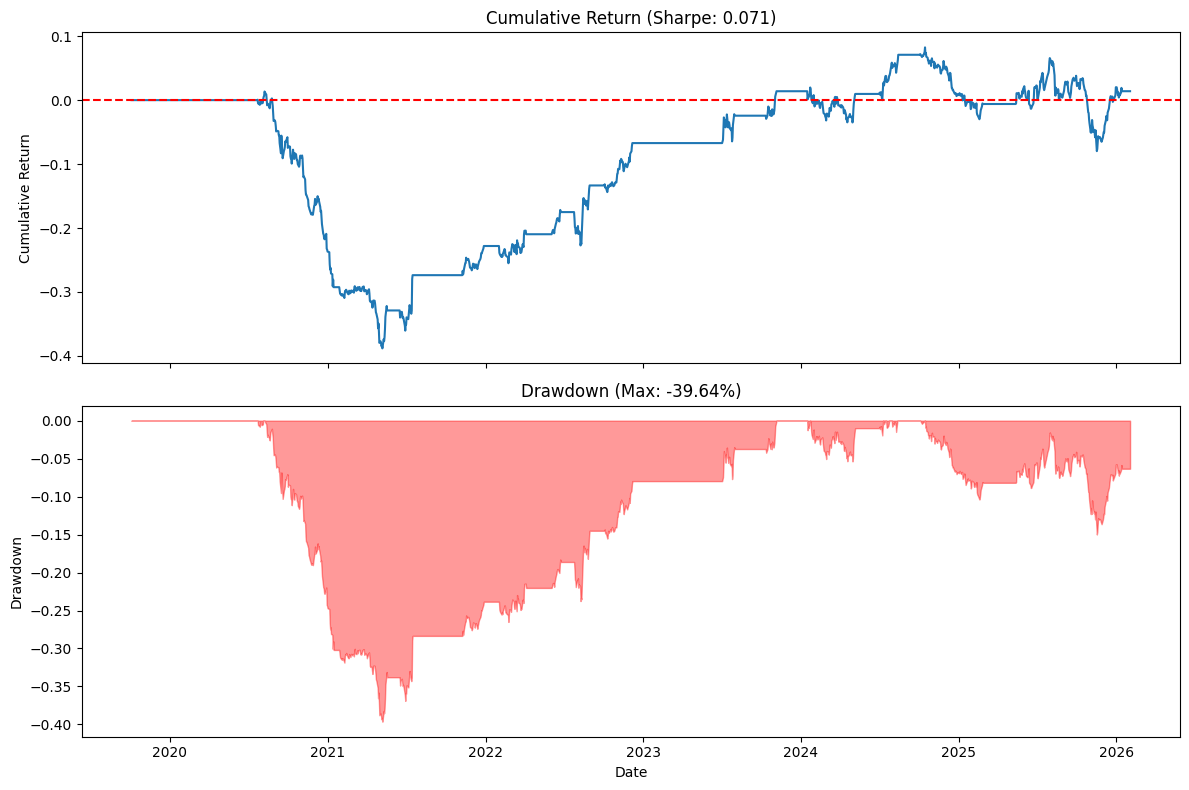

In [ ]:
positions_final=np.zeros(len(z_scores_test))
position_final=0
for i in range(len(z_scores_test)):
  if np.isnan(z_scores_test.iloc[i]):
    position_final = 0
  elif z_scores_test.iloc[i] >= THRESHOLD:
    position_final = -1
  elif z_scores_test.iloc[i] <= -THRESHOLD:
    position_final = 1
  elif position_final == 1 and z_scores_test.iloc[i] >= 0:
    position_final = 0
  elif position_final == -1 and z_scores_test.iloc[i] <= 0:
    position_final = 0
  positions_final[i] = position_final

split = int(len(df) * 0.7)
betas_test  = betas_final[split:]
soy_test    = df_test['Soybean'].values
corn_test   = df_test['Corn'].values
delta_soy   = df_test['Soybean'].diff().values
delta_corn  = df_test['Corn'].diff().values

pnl_fixed   = np.zeros(len(positions_final))
returns      = np.zeros(len(positions_final))
beta_entry   = np.nan
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i - 1]
    curr_pos = positions_final[i]

    if prev_pos == 0 and curr_pos != 0:
        beta_entry = betas_test[i]
        capital_entry = soy_test[i-1] + abs(beta_entry) * corn_test[i-1]

    if curr_pos != 0 and not np.isnan(beta_entry):
        pnl_fixed[i] = curr_pos * (delta_soy[i] - beta_entry * delta_corn[i])
        returns[i]   = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i]   = 0.0

    if curr_pos == 0:
        beta_entry = np.nan
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L (pts): {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

# Corn & Soybean Futures: Cointegration and Mean Reversion Strategy


---

## Methodology & Results

**1. Stationarity (ADF Test)**
Both series are I(1) — non-stationary in levels but stationary in 
first differences. This confirms the prerequisite for cointegration.

**2. Cointegration (CADF Test)**
Both variable orderings confirm cointegration at 95% confidence.
We select Soybean as dependent variable (most negative t-statistic = -3.789).
$$Spread(t) = Soybean(t) - 1.6645 \times Corn(t)$$

**3. Half-Life**
Estimated at **84 trading days** — tradeable but requires patience.
Lookback window set to 252 days for stability.

**4. Parameter Optimization (Training Set)**
Entry threshold optimized on training data — threshold = **1.5** 
achieves highest Sharpe ratio of 0.679 on training set.

**5. Backtest (Test Set: 2019–2026)**

| Metric | Value |
|--------|-------|
| Sharpe Ratio | **1.232** |
| Total P&L | **1525 points** |
| Max Drawdown | **-227 points** |

---

## Strategy Rules
- **Entry:** z > +1.5 → short spread | z < -1.5 → long spread
- **Exit:** z crosses zero

---

## Caveats
Transaction costs excluded. P&L in price points (cents/bushel). 
Test period includes COVID and Ukraine war — results may be 
inflated by unusually high volatility.